In [2]:
import pandas as pd
import numpy as np
import os

os.chdir('/Users/jonathanzhu/Documents/ev work/allegheny')
df = pd.read_csv('dhs_cleaned.csv')

# Plotting
Making visualizations is a key part of EDAs. So in order to plot, we will use packages `matplotlib` and `seaborn` to make some nice-looking plots.

The type of plot made typically depends on the type of the data used, whether it is a discrete category or a continuous number, as well as the number of variables analysed in a single plot. We will go over some good plots for categorical data later in this section, but a reference table for common plots is given below.

|  | One Variable | Two Variables |
| --- | --- | --- |
| Discrete | Bar Plot | Countplot, Jitterplot, Tornado/Butterfly Plot |
| Continuous | Histogram, Density, Dotplot | Scatterplot, Fitted Curve, Density Plot |
| One of Each |  | Column Plot, Boxplot, Violin Plot |

## Histograms
Histograms are a good way of looking at the overall distribution of a single feature, or column. 

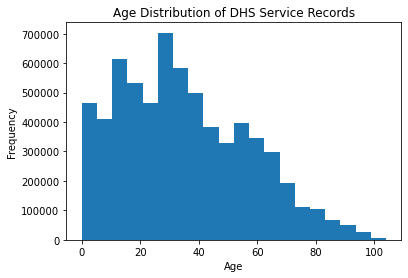

In [4]:
#here we want to make a histogram of the age column in the dataset
#using matplotlib.pyplot
import matplotlib.pyplot as plt

#since we already removed NA values, we can get straight to plotting
plt.hist(df['age'], bins=20)
#add some labels
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution of DHS Service Records')
plt.show()

## Scatter Plots
For looking at the relationship between two numerical variables, we turn to scatterplots. We can also add trend lines if we think there may be a relationship between the two. Unfortunately this dataset does not have multiple numerical variables, so only age.

However, a variation of scatterplots can also be used to visualize relationships between categorical variables. Here, we will assign various levels of the categories to one axis, and the number of points to the other. The hue can be used as another variable.

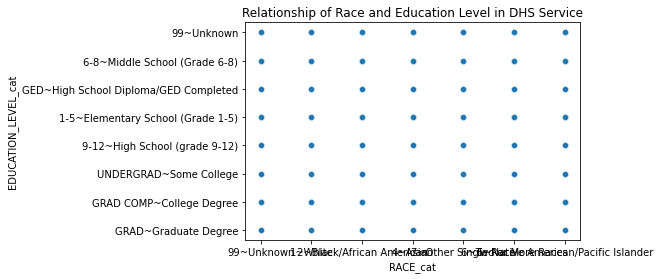

In [11]:
#making a seaborn countplot with x as RACE as x axis and EDUCATION_LEVEL as hue axis
import seaborn as sns

sns.scatterplot(data = df, x = "RACE_cat", y = "EDUCATION_LEVEL_cat")
plt.title("Relationship of Race and Education Level in DHS Service")
plt.show()

You might notice, however, that this plot is not very useful to us. This is because a point of each combination exists, so each intersection just shows up as a single dot. A better variation of this would be to adjust the size of the dots to show the number, or add some jitter to the points.

:::{admonition} Exercise 4.1
Add jitter or size to the above plot.
:::

## Boxplots
For looking at the relationship between two variables, one numeric and one categorical, we can use boxplots, which also give some information on the quartiles of the numeric variable.

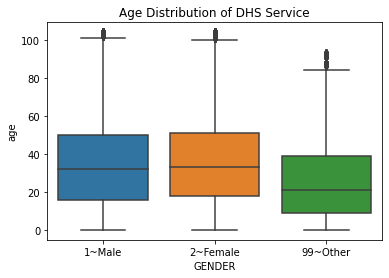

In [10]:
#we want to make a boxplot of age, separated by gender
#we can use seaborn for this
import seaborn as sns

sns.boxplot(data = df, x = "GENDER", y = "age")
plt.title('Age Distribution of DHS Service')
plt.show()

## Violin plots
A variation on the boxplot is the violin plot, which shows the relative distributions of each of the groups you are examining.

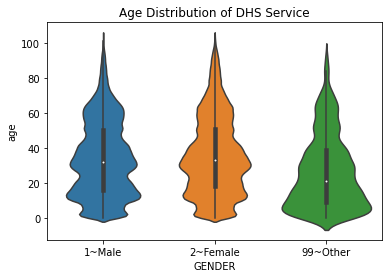

In [11]:
#we want to make the same as above, but with violin plots
sns.violinplot(data = df, x = "GENDER", y = "age")
plt.title('Age Distribution of DHS Service')
plt.show()

Note: I am not entirely sure what other plots to add due to the relative lack of numerical variables in this dataset. Age is really the only one. 

:::{admonition} Exercise 6.2
Refer to the documentation for `matplotlib` and `seaborn` to make a bar plot for one of the discrete variables in the dataset.
:::

:::{admonition} Exercise 6.3
Analyze the data and make more plots that make sense.
:::

## Interpreting Plots

Plotting is one thing, but plots alone do not make for good EDAs. Plots must be interpreted as well. This part can be subjective, but with each iteration of EDA, you will hopefully get better and better interpretations.

If we refer to the histogram of ages for this dataset, what can we interpret?

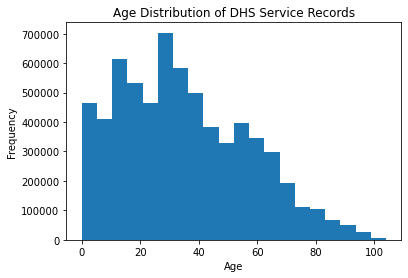

In [12]:
plt.hist(df['age'], bins=20)
#add some labels
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution of DHS Service Records')
plt.show()

We can see that the distribution of ages is right-skewed but is somewhat normally distributed. The mean and mode seem to be around the late 30's. But we can be more objective with our interpretations by adding these statistics to the plot.

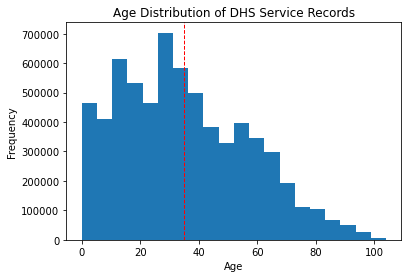

In [13]:
#remake previous histogram
#but add a line for the mean of the distribution
plt.hist(df['age'], bins=20)
#add some labels
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution of DHS Service Records')
plt.axvline(df['age'].mean(), color='red', linestyle='dashed', linewidth=1)
plt.show()

:::{admonition} Exercise 6.4
Repeat the above, adding the plot's estimated normal distribution.
:::

The exercise above asks to evaluate, visually, if this distribution approximately follows a normal distribution. The normal distribution is important for a myriad of statistical tests, which are discussed in the next section.

:::{admonition} Exercise 6.5
Refer to the documentation for `matplotlib` and `seaborn`. Look for a dataset on the Internet with numerical data and make some of the previously described plots.
:::

# Statistical Testing
While visualizations make for good reports and are a good way of visually looking at data, you can often get much more conclusive results about data by doing statistical tests. All statistical tests follow a principle of deviation from a *null hypothesis* $H_0$; this null hypothesis is what the tester assumes to be true. The tester then calculates the probability of the observations being the way they are given the null hypothesis; if the probability calculated is low, the tester can reject the null hypothesis. 

:::{warning} This is a massive simplification of the theory behind statistical testing. For more accurate theory, refer to the section on Statistical Inference.
:::

There are a myriad of statistical tests, most of which apply to numerical data, but a few of them apply to categorical data. As with plotting, different ones apply in different situations: whether or not we are comparing one or two samples, whether these samples follow a normal distribution, etc.

## Numerical Comparisons

In general, numerical comparison tests follow the null hypothesis of:
- (for one variable) The mean of the dataset is equal to a specific value
- (for two or more variables) The difference in the means of the groups is equal to zero

Tests involving numerical comparisons are split on how many groups are compared and whether or not these groups follow a normal distribution. The normal distribution assumption is critical for some of these tests; this is because the normal distribution was assumed in the making of these tests and therefore may give you incorrect conclusions if the data do not follow normal distributions when you use them.

|  | Analyzing One Variable | Analyzing Two Variables | Analyzing 3+ Variables |
| --- | --- | --- | --- |
| Normality Assumed | One-sample t-test | Two-sample t-test | ANOVA |
| Normality Not Assumed | Sign test | Mann-Whitney U-test, Wilcoxon signed-rank test | Kruskal-Wallis test |

:::{admonition} Exercise 6.6
Refer to the documentation of `scipy.stats`. Look for a dataset on the Internet and perform some of the tests described here.
:::

## Chi-Square Tests of Independence
A good way to compare two categorical datatypes is to use a chi-square test of independence. This can easily be called from packages in `scipy.stats`.

This test operates on the null hypothesis that the two categories are independent of each other; in other words, there exists no relationship between the two chosen variables. It creates a contingency table, splitting each variable on its own axis and putting the number of occurrences of each kind of data point in its respective box. For example:

| | Apples | Bananas |
| --- | --- | --- |
| Fresh | 30 | 27 |
| Frozen | 5 | 3 |

The above contingency table indicates that there are 30 occurrences of fresh apples in our pretend dataset. This data may have come from a dataset such as

| | Fruit Type | Quality |
| --- | --- | --- |
| 0 | Apple | Fresh |
| 1 | Banana | Fresh |
| 2 | Apple | Fresh |
| 3 | Apple | Frozen |
| ... | ... | ... |
| 64 | Banana | Frozen |

The contingency table then adds subtotals to each row and column; for example:

| | Apples | Bananas | Total |
| --- | --- | --- | --- |
| Fresh | 30 | 27 | 57 |
| Frozen | 5 | 3 | 8 |
| Total | 35 | 30 | 65 |

It then calculates an expected value for each entry by multiplying that entry's row and column totals, then dividing it by the total number of occurrences. So the expected number of frozen apples would be $\frac{35 * 57}{65} = 30.69$. This is done for all entries; the two tables are then compared for deviation from each other. 

For a dataset such as what we are using, doing this would be impossible by hand, but computers make it easy.

In [24]:
#we are going to do a chi-square test of independence
#to see if there is a relationship between RACE and EDUCATION_LEVEL
#we can use the scipy library for this
from scipy.stats import chi2_contingency

#first we get the categories from the race column
race_cats = df["RACE_cat"].astype('category').cat.categories
race = pd.Categorical(df["RACE_cat"], categories=race_cats)
#then same for education
edu_cats = df["EDUCATION_LEVEL_cat"].astype('category').cat.categories
edu = pd.Categorical(df["EDUCATION_LEVEL_cat"], categories=edu_cats)
#now the contingency table
tab = pd.crosstab(race, edu)

#now we can run the chi-square test
chi2, p, dof, expected = chi2_contingency(tab)
print("Chi-square test of independence: p = ", p, "chi2 = ", chi2)

Chi-square test of independence: p =  0.0 chi2 =  19200.2208703978


This incredibly high statistic and this very low p-value indicates that there is a dependency between race and education level. This may not be something we observed in the plots, especially with how many different levels we had for each category!

:::{admonition} Exercise 6.7
Perform another chi-square contingency test between two other variables in the dataset.
:::

While other categorical data tests exist, such as Fisher's Exact test and McNemar's test, they are not used very often in practice, especially for EDA. 

## Normality Tests

In practice, tests comparing numerical data may give you the same result regardless of what test you use. However, to assume that this will be the case is not good practice. It is better to perform both tests and analyze differences; if differences between the two tests' conclusions arise, then it is good to perform normality tests to narrow down which conclusion is more accurate.

Normality tests operate on the null hypothesis that there is no deviation from a normal distribution for a given dataset. Its associated p-value is low if there is significant deviation from a normal distribution and high if the data follow an approximate normal distribution.

There are many tests to analyze normality, but the one with the most power is the Shapiro-Wilk test.

:::{admonition} Exercise 6.8
Refer to the documentation for `scipy.stats`. Look for a dataset on the Internet with numerical data and perform some of the numerical and normality tests described here.